## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```


In [ ]:
# Assign your and your partner's names here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = ''

## **In Class Activity: Model Evaluation and Simple Ensembles**

In this notebook, you will practice two core machine learning skills:

- **model evaluation** using common classification metrics, and
- **ensemble methods** using a simple majority-vote approach across multiple classifiers.

We will use the breast cancer dataset from scikit-learn, which is a **binary classification** problem.

## **Why this matters**

A model can look good under one metric and weaker under another. In classification, it is important to evaluate performance from multiple perspectives:

- **Accuracy**: overall correctness
- **Precision**: how often positive predictions are correct
- **Recall**: how many true positives are found
- **F1 Score**: balance between precision and recall
- **ROC / AUC**: threshold-independent view of classifier ranking quality

You will also compare individual Random Forest models with a small voting ensemble to see how combining models can improve stability and performance.


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


### **Evaluation Metrics from Scratch**

In the previous class, you implemented these classification metrics from their formulas. We will reuse them here so you can apply them in a full evaluation workflow.

### **Why implement metrics manually?**

Writing the formulas yourself helps you understand what each metric emphasizes:
- `accuracy` rewards overall correctness
- `precision` penalizes false positives
- `recall` penalizes false negatives
- `f1_score` balances precision and recall

This understanding becomes important when choosing the right metric for a real problem.


In [2]:
def accuracy(y_true, y_pred):
    """
    Computes the accuracy score.

    Accuracy is the ratio of correctly predicted instances to the total instances.

    Formula:
        Accuracy = (Number of Correct Predictions) / (Total Number of Predictions)

    Args:
        y_true (list): True class labels.
        y_pred (list): Predicted class labels by the model.

    Returns:
        float: The accuracy score.

    TODO:
        - Implement the accuracy score calculation from scratch using the formula provided.

    """
    correct = sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

In [3]:
def recall(y_true, y_pred):
    """
    Computes the recall score.

    Recall (or Sensitivity or True Positive Rate) is the ratio of correctly predicted positive observations to the all observations in actual class.

    Formula:
        Recall = TP / (TP + FN)

    Args:
        y_true (list): True class labels.
        y_pred (list): Predicted class labels by the model.

    Returns:
        float: The recall score.

    TODO:
        - Implement the recall score calculation from scratch using the formula provided.


    """
    tp = sum((y_true == 1) & (y_pred == 1))
    fn = sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn)

In [4]:
def precision(y_true, y_pred):
    """
    Computes the precision score.

    Precision is the ratio of correctly predicted positive observations to the total predicted positives.

    Formula:
        Precision = TP / (TP + FP)

    Args:
        y_true (list): True class labels.
        y_pred (list): Predicted class labels by the model.

    Returns:
        float: The precision score.

    TODO:
        - Implement the precision score calculation from scratch using the formula provided.
    """
    tp = sum((y_true == 1) & (y_pred == 1))
    fp = sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp)

In [5]:
def f1_score(y_true, y_pred):
    """
    Computes the F1 score.

    The F1 score is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account.

    Formula:
        F1 Score = 2*(Recall * Precision) / (Recall + Precision)

    Args:
        y_true (list): True class labels.
        y_pred (list): Predicted class labels by the model.

    Returns:
        float: The F1 score.

    TODO:
        - Use the precision() and recall() functions to get the necessary values.
        - Implement the F1 score calculation from scratch using the formula provided.
    """
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r)

### **Training and Evaluating**

The helper function below trains a classifier, makes predictions, and visualizes its performance with an ROC curve.

### **What this function demonstrates**

- training a scikit-learn classifier
- generating class predictions (`predict`)
- generating probability scores (`predict_proba`) for ROC analysis
- computing ROC points and AUC
- plotting the ROC curve for interpretation

ROC/AUC is especially useful because it evaluates ranking performance across many classification thresholds, not just the default threshold.


In [6]:
def train_evaluate(clf, X_train, y_train, X_test, y_test):
    """
    Trains a given classifier on the provided training data, evaluates it on the test data, and then plots the ROC curve.

    The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary
    classifier system as its discrimination threshold is varied. The curve is plotted with the True Positive Rate against the
    False Positive Rate. The area under the curve (AUC) provides an aggregate measure of the model's performance across all
    possible classification thresholds.

    Args:
        clf (object): The classifier to be trained. Should have fit, predict, and predict_proba methods. -- Please note, here you are only using this parameter as a placeholder
        when this method is called, clf will need to have been initialized with a classifier from scikit-learn
        X_train (array-like): Training data features.
        y_train (array-like): Training data labels.
        X_test (array-like): Test data features.
        y_test (array-like): Test data labels.

    Returns:
        array-like: Predicted labels for the test data.

    TODO:
        - Train the classifier using the provided training data.
        - Predict the labels for the test data.
        - Predict the probability scores for the test data.
        - Compute the False Positive Rate and True Positive Rate.
        - Plot the ROC curve and display the AUC.
        - Return the predicted labels for the test data.


    """
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    return y_pred

### **TASK 1: Training a List of Classifiers with Different Hyperparameters**

The function below is implemented for you as an example of how to build and train a set of classifiers by iterating over a list of hyperparameter dictionaries.

### **Your task**

Review the implementation and write an appropriate docstring that clearly explains:
- the inputs (`X_train`, `y_train`, `hyperparameters_list`)
- what the function returns
- how the list of Random Forest models is created

This pattern is common in model experimentation and hyperparameter search workflows.


In [7]:
from sklearn.ensemble import RandomForestClassifier


def train_multiple_random_forests(X_train, y_train, hyperparameters_list):
    """
    TODO: Write docstring here
    Performs ensemble prediction using majority voting

    this function predicts the class labels for each classifier
    returns the majority class prediction for each instance

    Args:
        classifiers (list)
        X (array-like)

    Returns:
        Ensemble predicted labels for the data.
    """
    classifiers = []
    for hyperparams in hyperparameters_list:
        clf = RandomForestClassifier(**hyperparams) # this will later take a list of hyperparams with varying values when this function is called
        clf.fit(X_train, y_train)
        classifiers.append(clf)
    return classifiers


### **TASK 2: Ensemble Method**

Implement the `ensemble_predict()` function using a **majority voting** strategy.

### **How majority voting works (binary classification)**

Each classifier votes `0` or `1` for every sample. The ensemble prediction is based on the majority of votes across the models.

This simple voting approach can improve robustness when different models make different mistakes.


In [8]:
def ensemble_predict(classifiers, X):
    """
    Performs ensemble prediction using a majority voting mechanism.

    Given a list of classifiers, this function predicts the class labels for each classifier and then
    returns the majority class prediction for each instance in the dataset. In the case of binary classification,
    if more than half of the classifiers predict the positive class (1), then the ensemble prediction is 1;
    otherwise, it's 0.

    Args:
        classifiers (list): A list of trained classifiers. Each classifier should have a predict method.
        X (array-like): Data features for which the ensemble prediction is to be made.

    Returns:
        array-like: Ensemble predicted labels for the data.

    TODO:
        - Predict the labels for the data using each classifier.
        - Sum the predictions across classifiers for each data instance.
        - Determine the majority class for each data instance.
        - Return the ensemble predicted labels.

    Note:
        This implementation assumes binary classification. For multi-class classification,
        a more sophisticated voting mechanism would be required.


    """
    # write your code here
    predictions = np.array([clf.predict(X) for clf in classifiers])   # shape: (num_classifiers, num_samples)
    votes = np.sum(predictions, axis=0)                               # total votes for class 1
    majority_predictions = (votes > len(classifiers) / 2).astype(int)
    return majority_predictions

### **TASK 3: Train One `RandomForestClassifier` and Evaluate It**

Create a `RandomForestClassifier()` instance and call `train_evaluate()` on it to visualize its ROC curve.

### **Purpose of this step**

This gives you a single-model baseline before combining multiple Random Forest models into an ensemble.


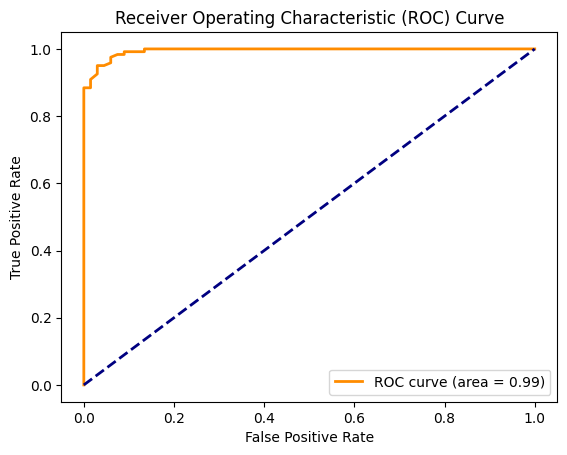

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1])

In [9]:
# A single RandomForest classifier to observe its ROC Curve
clf = RandomForestClassifier()
train_evaluate(clf, X_train, y_train, X_test, y_test)


In [10]:
hyperparameters_list = [
    {"n_estimators": 10, "max_depth": 3, "random_state": 42},
    {"n_estimators": 50, "max_depth": 5, "random_state": 42},
    {"n_estimators": 100, "max_depth": None, "random_state": 42}
]

### **TASK 4: Train Multiple Random Forests and Create Ensemble Predictions**

Use `train_multiple_random_forests()` to train a list of models with the provided hyperparameters, then call `ensemble_predict()` to generate predictions on `X_test`.

### **Why vary hyperparameters?**

Different Random Forest settings can produce slightly different decision boundaries. Combining them can sometimes improve generalization compared with relying on just one model.


In [11]:
classifiers = train_multiple_random_forests(X_train, y_train, hyperparameters_list)

# Ensemble predictions by calling `ensemble_predict() and passing the classifiers as well as the X_test to it.
ensemble_predictions = ensemble_predict(classifiers, X_test)

### **TASK 5: Compute Metrics Using the Functions You Were Provided**

Use your metric functions (`accuracy`, `precision`, `recall`, `f1_score`) to evaluate the ensemble predictions.

### **Goal**

This step connects the earlier “from scratch” metric functions to a real model evaluation pipeline.


* Let's see how they did!*

After computing the metrics, compare them together rather than reading only one value. A high accuracy score can still hide weak precision or recall in some problems.


In [ ]:

ensemble_accuracy = accuracy(y_test, ensemble_predictions)
ensemble_precision = precision(y_test, ensemble_predictions)
ensemble_recall = recall(y_test, ensemble_predictions)
ensemble_f1 = f1_score(y_test, ensemble_predictions)

print("Ensemble Metrics:")
print("Accuracy:", ensemble_accuracy)
print("Precision:", ensemble_precision)
print("Recall:", ensemble_recall)
print("F1 Score:", ensemble_f1)


Ensemble Metrics:
Accuracy: 0.9574468085106383
Precision: 0.959349593495935
Recall: 0.9752066115702479
F1 Score: 0.9672131147540983


: 

### **TASK 6: Create a Confusion Matrix with `ensemble_predictions`**

Compute and visualize a confusion matrix for the ensemble predictions.

### **Why a confusion matrix?**

A confusion matrix shows *where* the model is making mistakes (false positives vs false negatives), which helps interpret the metric scores more concretely.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix usiong confusion_matrix() method from scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
cm = ...

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# write your code here

### **Interpretation of Results**

The ensemble classifier performed very well on the test set, with high scores across all metrics. The model was particularly strong in recall, meaning it was very effective at identifying positive instances. The high F1 score suggests a balanced performance in terms of both precision and recall.

### **How to interpret this outcome**

- High **accuracy** indicates strong overall performance.
- High **precision** means positive predictions were usually correct.
- High **recall** means the model missed relatively few positive cases.
- High **F1 score** indicates a strong precision/recall balance.

Use the confusion matrix to verify which types of errors remain.


## **Summary and Key Takeaways**

### **What we practiced**

1. **Metrics from scratch**
- Implemented accuracy, precision, recall, and F1 score using their formulas

2. **Model evaluation workflow**
- Trained a classifier and evaluated predictions on a held-out test set
- Visualized ROC curve and interpreted AUC

3. **Training multiple models**
- Built several Random Forest classifiers with different hyperparameters

4. **Ensemble voting**
- Combined classifier predictions using majority voting for binary classification

5. **Performance interpretation**
- Compared metric values and used a confusion matrix to inspect prediction behavior

### **Best Practices**

- Use multiple metrics, not just accuracy
- Match metric choice to the cost of false positives vs false negatives
- Keep train/test splits fixed (`random_state`) for reproducibility
- Start with a simple ensemble baseline before moving to more complex methods
- Use confusion matrices and ROC/AUC together for richer model evaluation
